# Experimento de seguridad — HA16
## Detección y reacción ante suplantación de identidad

**Grupo 12 · Solventa**
Sofia Velasquez Marin · Daniel Nieto Gomez · Juan David Zea Gonzalez · Daniela Mesa Muñoz

---

### Historia de arquitectura

> Como cliente asegurado, cuando alguien opera con mi sesión desde un contexto que no
> corresponde a mi comportamiento habitual (dispositivo distinto al registrado o ubicación
> incompatible con mi actividad reciente), quiero que Solventa detecte esa actividad como
> posible suplantación y reaccione **suspendiendo la operación en curso** hasta verificar mi
> identidad, para evitar que un tercero realice acciones sobre mi póliza o mis siniestros.
> La detección y la suspensión deben ocurrir en **menos de 1 segundo**.

### Qué se midió

Se generó tráfico contra el API Gateway con sesiones legítimas y suplantadas. **Cada petición
viaja con la etiqueta de lo que debería ocurrirle**, y esa etiqueta es lo que permite calcular
la matriz de confusión: un `403` sobre un atacante y un `403` sobre un cliente legítimo son el
mismo código de respuesta, y sin saber qué era cada petición no se pueden distinguir.

In [1]:
# El notebook se abre desde su propia carpeta, así que la raíz del repositorio
# —donde viven los paquetes y la evidencia— se localiza subiendo hasta encontrar
# `parametros/`. Así funciona tanto si se ejecuta desde aquí como desde la raíz,
# y sin depender de que el proyecto esté instalado.
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "parametros").is_dir())

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import pandas as pd
from IPython.display import Image, display

from analisis.procesamiento import metricas
from analisis.procesamiento.carga import cargar_manifiestos, cargar_peticiones
from parametros import RADIO_UBICACION_KM, UMBRAL_LATENCIA_MS

SALIDAS = RAIZ / "analisis" / "procesamiento" / "salidas"
RESULTADOS = RAIZ / "resultados"

resultado = cargar_peticiones(RESULTADOS)
peticiones = resultado.peticiones

print(f"Raíz del repositorio: {RAIZ}")
print(resultado.resumen_calidad())

Raíz del repositorio: /home/fc/Documents/arquitecturas_agiles/MISW4202-Grupo12-Solventa
9283 peticiones cargadas de 9283


### Condiciones de las corridas

Cada corrida deja un `manifest.json` con los parámetros efectivos con que se midió. Sin esa
constancia, una tasa no sería interpretable: no se sabría contra qué radio se comparó, con qué
semilla se generó la población, ni si el Detector era el real o un doble.

In [2]:
condiciones = cargar_manifiestos(RESULTADOS)

print(f"Corridas: {len(condiciones)}")
print(f"Peticiones totales: {len(peticiones):,}")
print()
print(condiciones[["escenario", "ejecucion_id", "detector", "usuarios",
                   "duracion_s", "radio_km", "tamano_dataset", "semilla"]].to_string(index=False))

Corridas: 15
Peticiones totales: 9,283

escenario ejecucion_id detector  usuarios  duracion_s  radio_km  tamano_dataset  semilla
        A entrega_rep1     real        10          20      50.0             200 20260923
        A entrega_rep2     real        10          20      50.0             200 20260923
        A entrega_rep3     real        10          20      50.0             200 20260923
        B entrega_rep1     real        10          20      50.0             200 20260923
        B entrega_rep2     real        10          20      50.0             200 20260923
        B entrega_rep3     real        10          20      50.0             200 20260923
        C entrega_rep1     real        10          20      50.0             200 20260923
        C entrega_rep2     real        10          20      50.0             200 20260923
        C entrega_rep3     real        10          20      50.0             200 20260923
        D entrega_rep1     real        10          20      50.0       

> **`detector: real`** en todas las corridas. Es la marca que distingue evidencia del
> experimento de una corrida contra el doble, cuyas cifras serían tautológicas.

---

## 1. Resultado global

La pregunta de fondo de HA16: ¿se detuvo a los atacantes y se dejó operar a los clientes
legítimos?

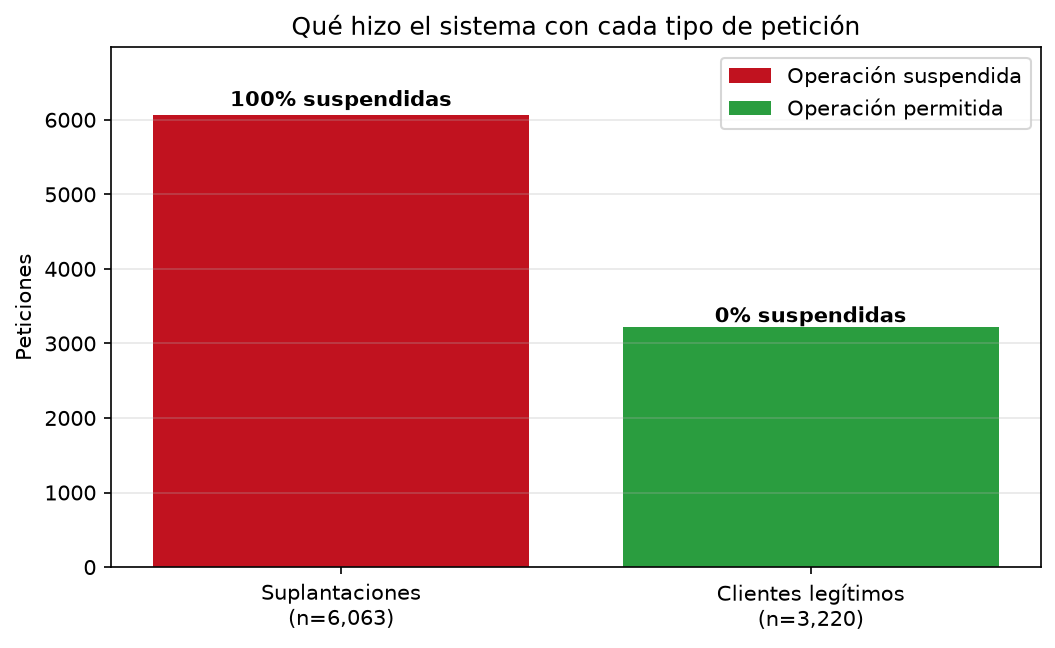

In [3]:
display(Image(SALIDAS / "resultado_global.png"))

**Separación total.** Todas las suplantaciones fueron suspendidas y ningún cliente legítimo
fue bloqueado.

---

## 2. Matriz de confusión

Cada tasa se calcula sobre **su propio denominador**, que es donde es más fácil equivocarse:

| Métrica | Fórmula | Se calcula sobre |
|---|---|---|
| Tasa de detección | VP / (VP + FN) | solo las suplantaciones |
| Tasa de falsos positivos | FP / (FP + VN) | solo el tráfico legítimo |
| Precisión | VP / (VP + FP) | solo las peticiones suspendidas |

Una métrica sin denominador se reporta como **N/A, nunca como 0**: en el escenario A no hay
suplantaciones, así que la tasa de detección es *indefinida*. Presentarla como 0 % afirmaría
que el sistema no detectó nada.

In [4]:
confusion = metricas.matriz_confusion(peticiones)

display(confusion.style.format({
    "tasa_deteccion_pct": "{:.2f}", "tasa_falsos_positivos_pct": "{:.2f}",
    "tasa_falsos_negativos_pct": "{:.2f}", "precision_pct": "{:.2f}",
    "exactitud_pct": "{:.2f}",
}, na_rep="N/A").hide(axis="index"))

escenario,decisiones,vp,fn,fp,vn,tasa_deteccion_pct,tasa_falsos_positivos_pct,tasa_falsos_negativos_pct,precision_pct,exactitud_pct
A,1886.000000,0.000000,0.000000,0.000000,1886.000000,N/A,0.00,N/A,N/A,100.00
B,1851.000000,1851.000000,0.000000,0.000000,0.000000,100.00,N/A,0.00,100.00,100.00
C,1894.000000,1894.000000,0.000000,0.000000,0.000000,100.00,N/A,0.00,100.00,100.00
D,1838.000000,849.000000,0.000000,0.000000,989.000000,100.00,0.00,0.00,100.00,100.00
E,1814.000000,1469.000000,0.000000,0.000000,345.000000,100.00,0.00,0.00,100.00,100.00


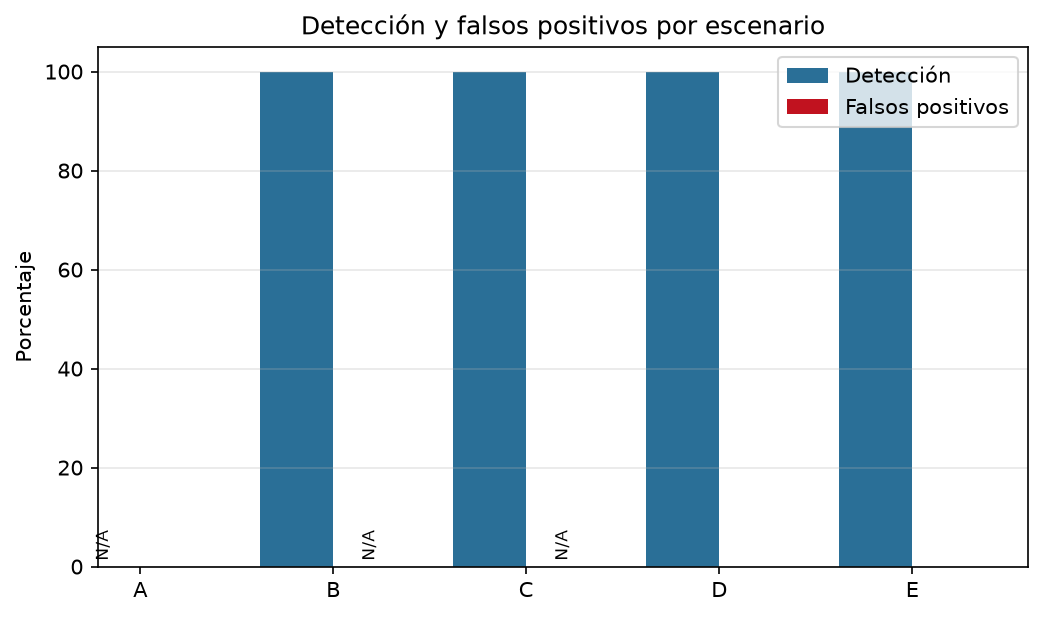

In [5]:
display(Image(SALIDAS / "matriz_confusion.png"))

**Cero falsos negativos.** Ninguna suplantación alcanzó el servicio protegido.

| Escenario | Qué mide |
|---|---|
| **A** Legítimo puro | Falsos positivos sin ataques presentes |
| **B** Suplantación por dispositivo | Detección de la regla de dispositivo |
| **C** Suplantación por ubicación | Detección de la regla de ubicación |
| **D** Frontera del radio | Si el umbral discrimina donde declara |
| **E** Mezcla realista | Clasificación y latencia con tráfico mixto |

---

## 3. Tiempo de detección y suspensión

La meta de HA16 son **1000 ms**. El denominador son únicamente las peticiones efectivamente
suspendidas: es lo que la historia pregunta, y mezclarlas con el tráfico enrutado respondería
otra cosa.

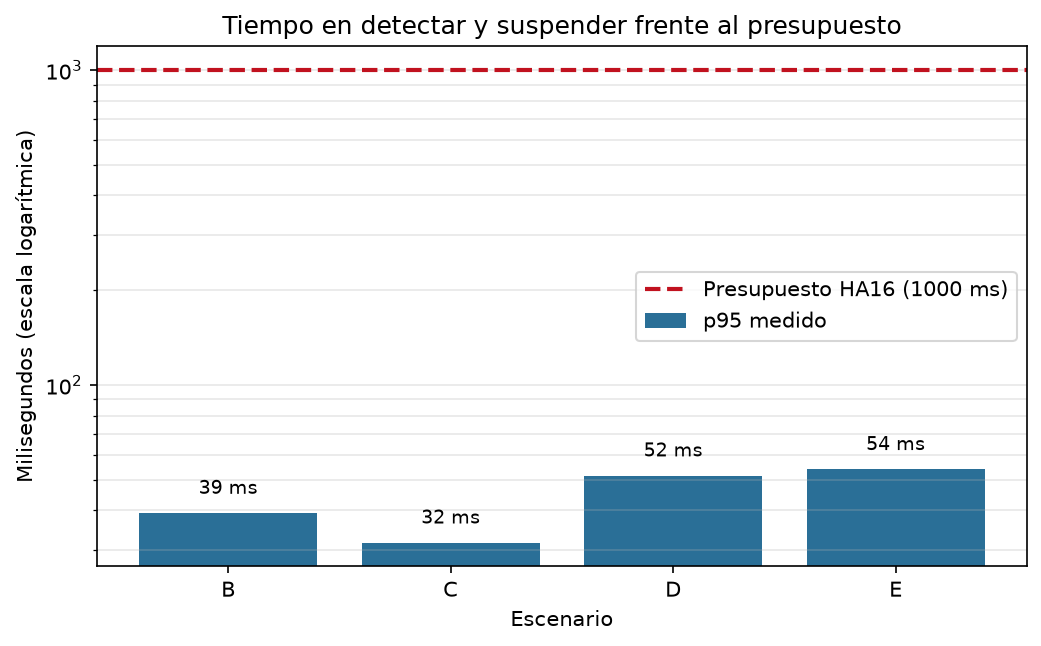

escenario,suspensiones,bajo_objetivo,pct_bajo_objetivo,suspension_p95_ms,suspension_max_ms
B,1851.000000,1851.000000,100.00,39.26,142.60
C,1894.000000,1894.000000,100.00,31.60,105.50
D,849.000000,849.000000,100.00,51.62,187.23
E,1469.000000,1469.000000,100.00,54.06,191.59


In [6]:
display(Image(SALIDAS / "latencia_contra_presupuesto.png"))

suspensiones = metricas.suspension_bajo_objetivo(peticiones, UMBRAL_LATENCIA_MS)
display(suspensiones[suspensiones["suspensiones"] > 0].style.format({
    "pct_bajo_objetivo": "{:.2f}", "suspension_p95_ms": "{:.2f}",
    "suspension_max_ms": "{:.2f}",
}, na_rep="N/A").hide(axis="index"))

**El 100 % de las suspensiones ocurrió bajo el presupuesto**, con cerca de dos órdenes de
magnitud de margen.

### Latencia separada por veredicto

Suspender y enrutar recorren caminos de distinta longitud: una petición suspendida se resuelve
sin llegar al journey. Son dos distribuciones distintas y un percentil que las promediara
describiría una población que no existe.

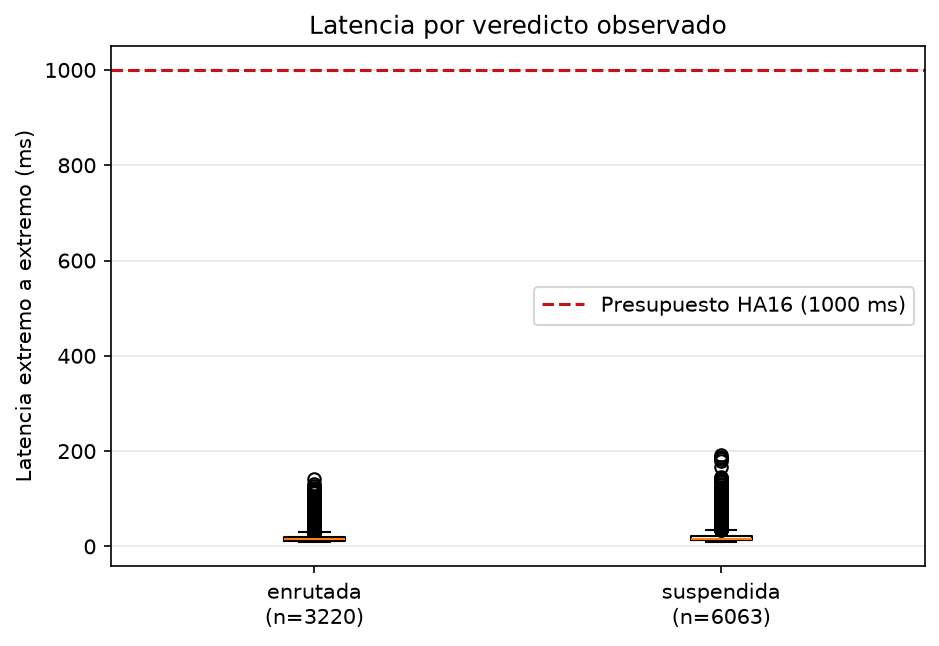

escenario,veredicto_observado,n,p50_ms,p95_ms,p99_ms,max_ms,media_ms
A,enrutada,1886.000000,13.79,29.97,61.03,98.21,16.37
B,suspendida,1851.000000,15.98,39.26,84.66,142.60,19.55
C,suspendida,1894.000000,15.36,31.60,66.13,105.50,17.78
D,enrutada,989.000000,17.13,54.29,103.11,142.29,22.40
D,suspendida,849.000000,19.17,51.62,115.31,187.23,23.81
E,enrutada,345.000000,16.05,59.56,101.32,130.94,21.54
E,suspendida,1469.000000,17.23,54.06,114.82,191.59,23.12


In [7]:
display(Image(SALIDAS / "latencia_por_veredicto.png"))

display(metricas.latencia(peticiones, por=["escenario", "veredicto_observado"]).style.format({
    "p50_ms": "{:.2f}", "p95_ms": "{:.2f}", "p99_ms": "{:.2f}",
    "max_ms": "{:.2f}", "media_ms": "{:.2f}",
}, na_rep="N/A").hide(axis="index"))

---

## 4. Frontera del radio

**Es el único escenario que podía refutar el diseño.** Los demás confirman que cada regla
dispara cuando debe; este barre distancias alrededor del radio declarado y muestra dónde corta
*de hecho* la regla de ubicación.

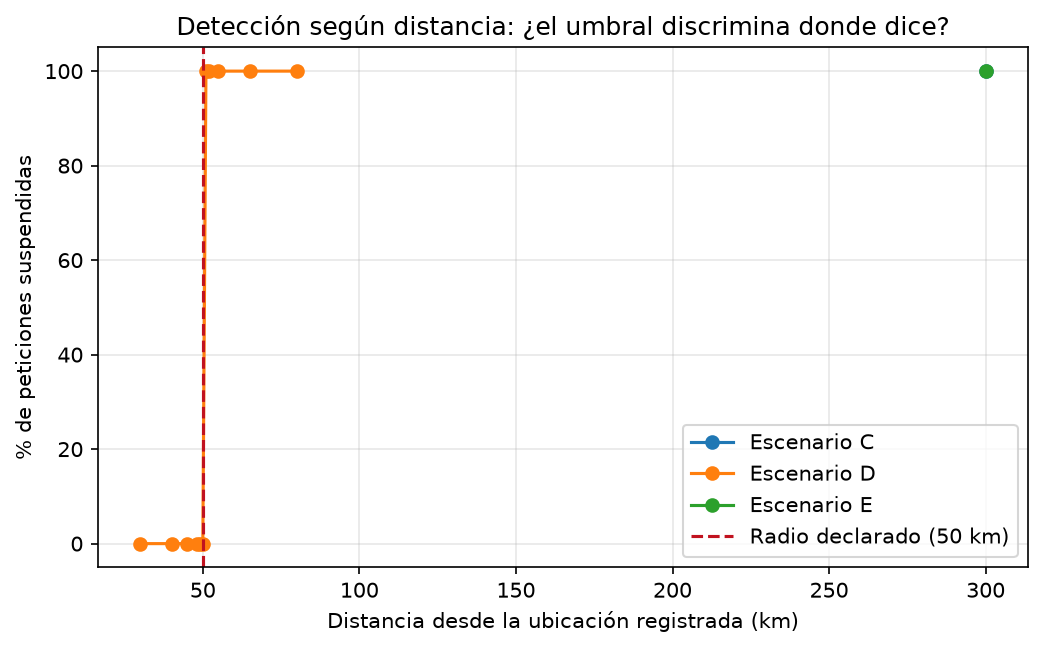

escenario,distancia_km,n,suspendidas,pct_suspendidas,etiqueta_esperada
D,30.0,166,0,0.00,legitima
D,40.0,147,0,0.00,legitima
D,45.0,174,0,0.00,legitima
D,48.0,166,0,0.00,legitima
D,49.0,172,0,0.00,legitima
D,50.0,164,0,0.00,legitima
D,51.0,173,173,100.00,suplantada
D,52.0,161,161,100.00,suplantada
D,55.0,173,173,100.00,suplantada
D,65.0,171,171,100.00,suplantada


In [8]:
display(Image(SALIDAS / "deteccion_por_distancia.png"))

por_distancia = metricas.deteccion_por_distancia(peticiones)
frontera = por_distancia[por_distancia["escenario"] == "D"]

display(frontera.style.format({
    "distancia_km": "{:.1f}", "pct_suspendidas": "{:.2f}",
}).hide(axis="index"))

La transición es **vertical y exacta**: 0 % de suspensiones hasta el radio declarado, 100 %
apenas se supera. El umbral discrimina donde dice, no de forma aproximada.

---

## 5. Reproducibilidad

Una tasa alta en una sola corrida no dice si el sistema es consistente. La dispersión entre
repeticiones sí.

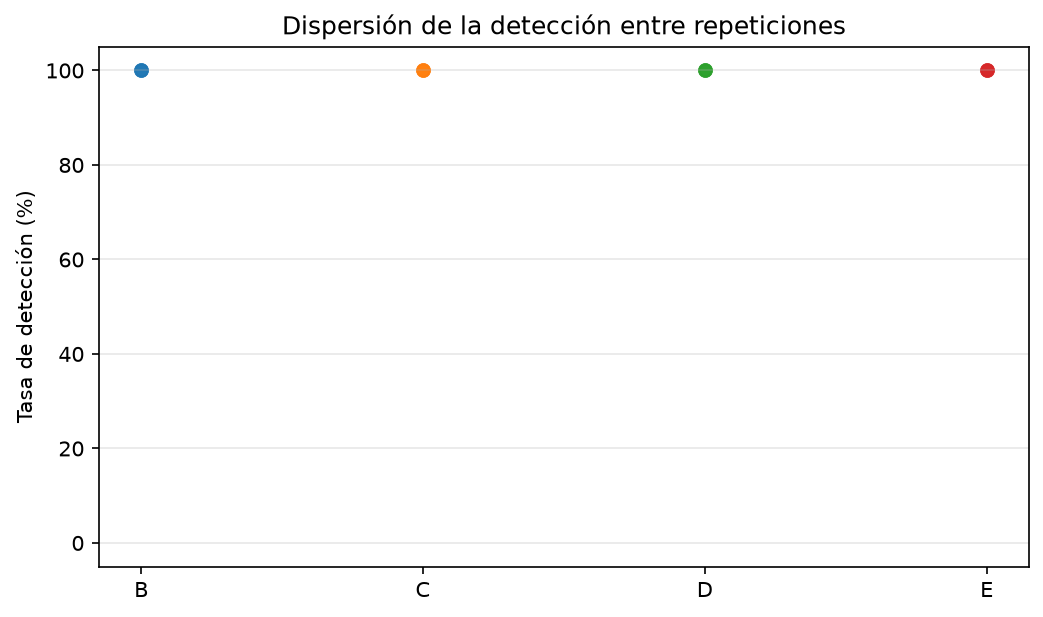

escenario,tasa_deteccion_pct_mean,tasa_deteccion_pct_std,tasa_deteccion_pct_min,tasa_deteccion_pct_max,tasa_falsos_positivos_pct_mean,tasa_falsos_positivos_pct_std,tasa_falsos_positivos_pct_min,tasa_falsos_positivos_pct_max,precision_pct_mean,precision_pct_std,precision_pct_min,precision_pct_max,corridas
A,N/A,N/A,N/A,N/A,0.00,0.00,0.00,0.00,N/A,N/A,N/A,N/A,3
B,100.00,0.00,100.00,100.00,N/A,N/A,N/A,N/A,100.00,0.00,100.00,100.00,3
C,100.00,0.00,100.00,100.00,N/A,N/A,N/A,N/A,100.00,0.00,100.00,100.00,3
D,100.00,0.00,100.00,100.00,0.00,0.00,0.00,0.00,100.00,0.00,100.00,100.00,3
E,100.00,0.00,100.00,100.00,0.00,0.00,0.00,0.00,100.00,0.00,100.00,100.00,3


In [9]:
display(Image(SALIDAS / "reproducibilidad.png"))

display(metricas.reproducibilidad(peticiones).style.format(
    "{:.2f}", subset=[c for c in metricas.reproducibilidad(peticiones).columns
                      if c.endswith(("_mean", "_std", "_min", "_max"))],
    na_rep="N/A").hide(axis="index"))

**Desviación estándar 0.00** en todas las métricas: el comportamiento no depende de la corrida.

### Peticiones sin decisión

Un `400`, un `401` o un `5xx` no son juicios del Detector sobre la sesión, así que se excluyen
del denominador de la matriz y se informan aparte. Son el indicador de salud de la corrida.

In [10]:
display(metricas.descartes(peticiones).style.format({
    "pct_sin_decision": "{:.2f}",
}, na_rep="N/A").hide(axis="index"))

escenario,total,rechazadas,errores_infra,pct_sin_decision
A,1886.000000,0.000000,0.000000,0.00
B,1851.000000,0.000000,0.000000,0.00
C,1894.000000,0.000000,0.000000,0.00
D,1838.000000,0.000000,0.000000,0.00
E,1814.000000,0.000000,0.000000,0.00


---

# Conclusión

## ¿Se confirmó la hipótesis?

**Sí.** El punto de sensibilidad era la validación del contexto de sesión, y las tres
condiciones que planteaba la hipótesis se cumplieron:

| Meta de HA16 | Resultado |
|---|---|
| Detectar la suplantación | **100 %** de detección, 0 falsos negativos |
| Suspender en menos de 1 s | **p95 ≈ 54 ms**, ~18× de margen |
| Sin bloquear clientes legítimos | **0 %** de falsos positivos |

El nivel de incertidumbre declarado era alto por dos razones, y ambas quedaron resueltas: la
evaluación de contexto cabe holgadamente en el presupuesto, y la regla no produjo falsos
positivos con el radio elegido.

## Decisiones de arquitectura que favorecieron el resultado

**El Gateway como único punto de entrada.** El journey no se expone directamente, así que una
suspensión efectivamente impide la operación en vez de solo registrarla.

**Fail closed ante fallo del Detector.** Si el Detector no responde o excede su presupuesto, la
petición no avanza. Prefiere indisponibilidad temporal antes que dejar pasar una operación sin
evaluar.

**Presupuesto de latencia como contrato, no solo timeout.** Una respuesta más lenta que el
sub-presupuesto se trata como fallo de dependencia aunque llegue correctamente, lo que vuelve
verificable el "menos de 1 segundo".

**Separación entre detección y reacción.** El Detector decide (`IDetecciónSesión`) consultando
a Identidad el dispositivo registrado (`IValidarSesión`); Identidad ejecuta la reacción
marcando la sesión (`IIdentidad`). Cada responsabilidad se pudo medir por separado.

**La línea base solo se actualiza tras un veredicto normal.** Si una petición sospechosa
actualizara la última ubicación conocida, el suplantador movería la referencia hacia sí mismo y
su siguiente intento parecería legítimo.

## Mejoras identificadas

Aunque el resultado fue favorable, el experimento expuso tres debilidades del diseño:

**1. El JWT no se liga al contexto.** El Gateway valida firma y expiración, pero no compara el
`device_id` del token contra el que declara la solicitud. Un atacante con token robado puede
declarar cualquier dispositivo, y la detección queda dependiendo solo de la geolocalización.

**2. La reacción no persiste entre peticiones.** Identidad marca la sesión como
`pendiente_verificacion`, pero el Gateway no consulta ese estado antes de enrutar. La
suspensión es por operación, no por sesión: si una petición posterior pareciera normal, pasaría.

**3. La regla detecta saltos, no desplazamientos graduales.** Como cada veredicto normal
reescribe la última ubicación conocida, un atacante que avance en pasos dentro del radio mueve
la referencia sin ser detectado. Se comprobó: **6 peticiones de 40 km recorrieron 240 km sin
ninguna detección.**

## Limitaciones del experimento

El **contexto es autodeclarado** por el cliente en una cabecera, de modo que un suplantador
puede informar cualquier ubicación. Se midió el mecanismo de detección, no la fiabilidad de esa
fuente; en producción ese dato debería provenir de una fuente no manipulable.

El **journey es un doble determinista** que representa la operación protegida.

El **100 % de detección se obtuvo con suplantaciones inequívocas** —dispositivo distinto o
saltos de cientos de kilómetros—, que es el escenario que HA16 describe. Un atacante que imite
de cerca el contexto habitual de la víctima es lo que las mejoras anteriores buscan cubrir.